# Sound Event Classification Project
## ESC-50 Dataset

This project focuses on classifying environmental sounds using both classical machine learning and deep learning techniques. Different feature representations and models are explored and compared to determine the most effective approach.

In [4]:
!pip install librosa audiomentations

## Classical Machine Learning Approach

In [5]:
import os
import numpy as np
import pandas as pd
import librosa
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix

from sklearn.preprocessing import StandardScaler

from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau # Ensure these are imported and active
from audiomentations import Compose, AddGaussianNoise, PitchShift, TimeStretch


## Dataset Loading

In this section, we load the ESC-50 dataset, which contains 2000 environmental audio recordings distributed across 50 classes. The dataset metadata provides information about file names and class labels.

In [6]:
!git clone https://github.com/karolpiczak/ESC-50.git

fatal: destination path 'ESC-50' already exists and is not an empty directory.


In [7]:

meta = pd.read_csv("/content/ESC-50/meta/esc50.csv")
audio_path = "/content/ESC-50/audio/"

## ESC-50 Dataset Classes

In [8]:
class_mapping = meta[['target', 'category']].drop_duplicates().sort_values('target').reset_index(drop=True)
display(class_mapping)

,target,category
0,0,dog
1,1,rooster
2,2,pig
3,3,cow
4,4,frog
5,5,cat
6,6,hen
7,7,insects
8,8,sheep
9,9,crow


## Feature Extraction (Classical Machine Learning)

To train classical machine learning models, audio signals are converted into numerical features. We use:

- MFCC (Mel Frequency Cepstral Coefficients)
- Mel Spectrogram

These features summarize audio signals and make them suitable for models such as SVM ,RF and KNN.

In [19]:
def extract_mfcc(file_path):
    y, sr = librosa.load(file_path, duration=5)
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=40)

    mfcc_mean = np.mean(mfcc.T, axis=0)
    mfcc_std = np.std(mfcc.T, axis=0)

    return np.hstack((mfcc_mean, mfcc_std))

In [20]:
def extract_melspec(file_path):
    y, sr = librosa.load(file_path, duration=5)
    mel = librosa.feature.melspectrogram(y=y, sr=sr)
    mel_db = librosa.power_to_db(mel)

    mel_mean = np.mean(mel_db.T, axis=0)
    mel_std = np.std(mel_db.T, axis=0)

    return np.hstack((mel_mean, mel_std))

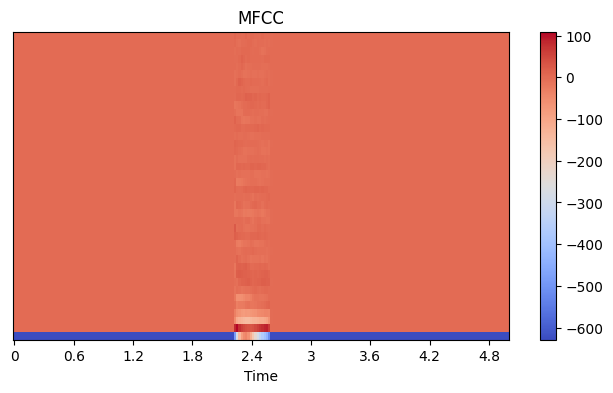

In [15]:
import librosa.display

file_path = os.path.join(audio_path, meta.iloc[0]["filename"])

y, sr = librosa.load(file_path)

mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=40)

plt.figure(figsize=(8,4))
librosa.display.specshow(mfcc, sr=sr, x_axis='time')
plt.colorbar()
plt.title("MFCC")

plt.savefig("mfcc.png")
plt.show()

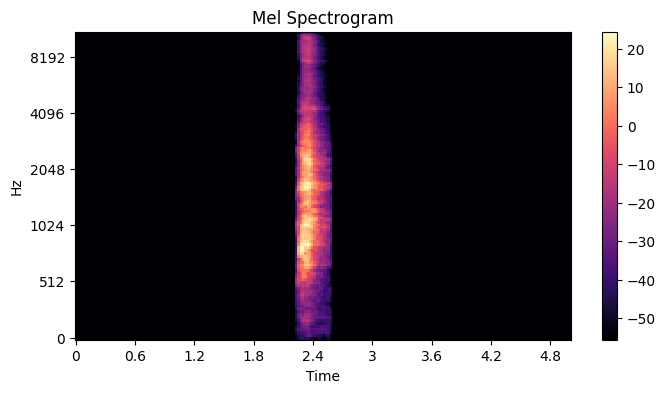

In [16]:
mel = librosa.feature.melspectrogram(y=y, sr=sr)
mel_db = librosa.power_to_db(mel)

plt.figure(figsize=(8,4))
librosa.display.specshow(mel_db, sr=sr, x_axis='time', y_axis='mel')
plt.colorbar()
plt.title("Mel Spectrogram")

plt.savefig("mel_spectrogram.png")
plt.show()

BUILD DATASET (ML)

In [21]:
def build_dataset(feature_func):
    X, y = [], []

    for _, row in meta.iterrows():
        file_path = os.path.join(audio_path, row["filename"])

        features = feature_func(file_path)

        X.append(features)
        y.append(row["target"])

    return np.array(X), np.array(y)

Classical Machine Learning Models

In this section, we train and evaluate different machine learning models, including:

- K-Nearest Neighbors (KNN)
- Support Vector Machine (SVM)
- Random Forest

These models are trained using extracted features (MFCC and Mel Spectrogram), and their performance is compared using accuracy.

The dataset was split into 80% training and 20% testing samples. This resulted in 1600 samples for training and 400 for testing. Each sample contains 80 features, and the model is evaluated on unseen test data to measure its performance.


In [18]:
models = {
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "SVM": SVC(kernel='rbf', C=10, gamma='scale'),
    "RF": RandomForestClassifier(n_estimators=200)
}

In [19]:
def run_experiment(X, y, model, name):

    #  SCALE DATA
    scaler = StandardScaler()
    X = scaler.fit_transform(X)

    # split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    # train
    model.fit(X_train, y_train)

    # predict
    y_pred = model.predict(X_test)

    # accuracy
    acc = accuracy_score(y_test, y_pred)

    print(f"{name} Accuracy: {acc:.4f}")

    return y_test, y_pred, acc


In [20]:
results = {}

# ===== MFCC =====
print("Running MFCC Experiments...")
X_mfcc, y = build_dataset(extract_mfcc)

for model_name, model in models.items():
    y_test, y_pred, acc = run_experiment(X_mfcc, y, model, f"MFCC + {model_name}")
    results[f"MFCC + {model_name}"] = (y_test, y_pred, acc)

Running MFCC Experiments...
MFCC + KNN Accuracy: 0.4075
MFCC + SVM Accuracy: 0.6375
MFCC + RF Accuracy: 0.5300


In [21]:
# ===== MEL SPECTROGRAM =====
print("\nRunning Mel Spectrogram Experiments...")
X_mel, y = build_dataset(extract_melspec)

for model_name, model in models.items():
    y_test, y_pred, acc = run_experiment(X_mel, y, model, f"MelSpec + {model_name}")
    results[f"MelSpec + {model_name}"] = (y_test, y_pred, acc)


Running Mel Spectrogram Experiments...
MelSpec + KNN Accuracy: 0.3550
MelSpec + SVM Accuracy: 0.5425
MelSpec + RF Accuracy: 0.4550


MFCC + SVM CONFUSION MATRIX

In [22]:
def plot_cm(y_test, y_pred, title):
    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(8,6))
    sns.heatmap(cm, cmap="Blues")
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.show()

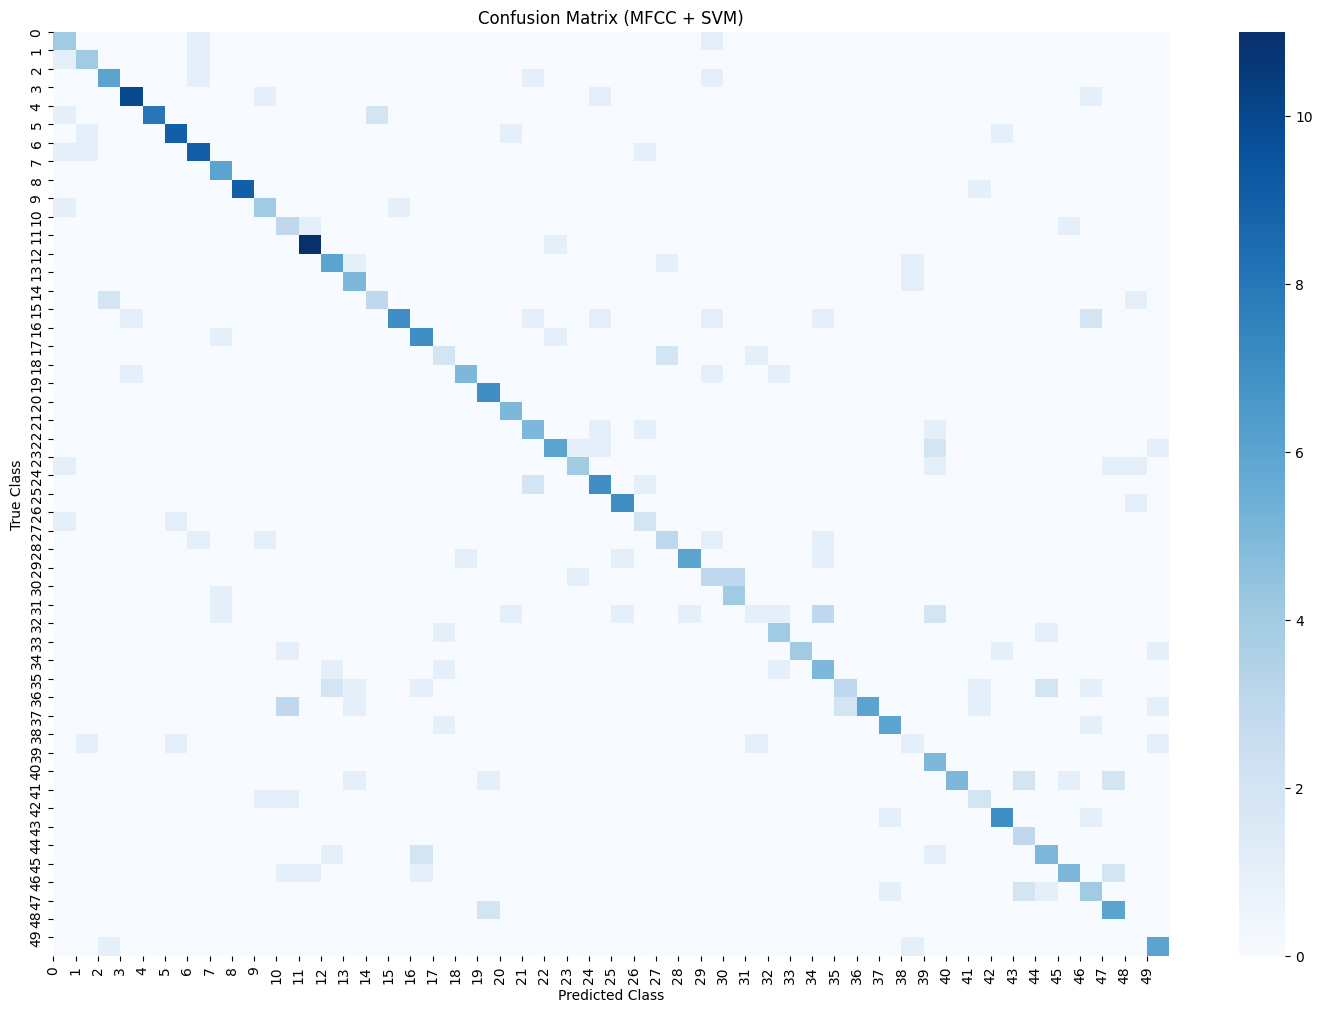

In [23]:
y_true_mfcc_svm, y_pred_mfcc_svm, _ = results["MFCC + SVM"]
cm = confusion_matrix(y_true_mfcc_svm, y_pred_mfcc_svm)

plt.figure(figsize=(18,12))
sns.heatmap(cm, cmap='Blues')

# show class numbers (0–49)
plt.xticks(ticks=np.arange(50), labels=np.arange(50), rotation=90)
plt.yticks(ticks=np.arange(50), labels=np.arange(50))

plt.xlabel("Predicted Class")
plt.ylabel("True Class")
plt.title("Confusion Matrix (MFCC + SVM)")

plt.show()

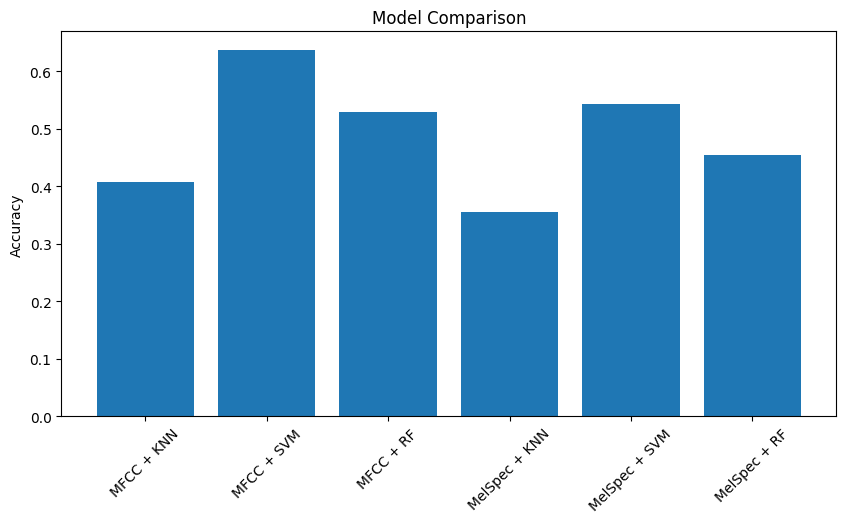

In [24]:
names = list(results.keys())
scores = [v[2] for v in results.values()]

plt.figure(figsize=(10,5))
plt.bar(names, scores)
plt.xticks(rotation=45)
plt.ylabel("Accuracy")
plt.title("Model Comparison")
plt.show()

# Deep Learning Approach (CNN)
In this section, we apply CNN models to MFCC and Mel Spectrogram features.

In [11]:
def extract_mfcc(file_path):
    y, sr = librosa.load(file_path, duration=5)

    #  more MFCC info
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=64)

    #  temporal info
    delta = librosa.feature.delta(mfcc)

    #  combine
    mfcc = np.vstack((mfcc, delta))   # shape → (128, time)

    #  fix size
    mfcc = librosa.util.fix_length(mfcc, size=128, axis=1)

    return mfcc

In [12]:
X = []
y = []

for _, row in meta.iterrows():
    file_path = os.path.join(audio_path, row["filename"])

    mfcc = extract_mfcc(file_path)

    X.append(mfcc)
    y.append(row["target"])

X = np.array(X)[..., np.newaxis]
y = to_categorical(np.array(y), 50)

print("Shape:", X.shape)

Shape: (2000, 128, 128, 1)


In [13]:
X = (X - np.mean(X, axis=(1,2,3), keepdims=True)) / np.std(X, axis=(1,2,3), keepdims=True)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42
)


In [14]:
model = Sequential([

    Conv2D(32, (3,3), activation='relu', input_shape=(128,128,1)),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),

    Dense(256, activation='relu'),
    Dropout(0.5),

    Dense(50, activation='softmax')
])
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     6,422,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 50)             │        12,850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,528,306 (24.90 MB)

 Trainable params: 6,528,306 (24.90 MB)

 Non-trainable params: 0 (0.00 B)

In [15]:
optimizer = tf.keras.optimizers.Adam(learning_rate=0.0005)

model.compile(
    optimizer=optimizer,
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [30]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

lr_reduce = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.3,
    patience=3
)

history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_data=(X_val, y_val),
    callbacks=[early_stop, lr_reduce]
)


Epoch 1/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 60s 1s/step - accuracy: 0.0550 - loss: 3.7901 - val_accuracy: 0.0800 - val_loss: 3.5270 - learning_rate: 5.0000e-04
Epoch 2/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 72s 1s/step - accuracy: 0.1493 - loss: 3.3131 - val_accuracy: 0.2133 - val_loss: 2.9814 - learning_rate: 5.0000e-04
Epoch 3/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 81s 1s/step - accuracy: 0.2271 - loss: 2.8759 - val_accuracy: 0.3333 - val_loss: 2.6107 - learning_rate: 5.0000e-04
Epoch 4/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 83s 1s/step - accuracy: 0.3071 - loss: 2.5281 - val_accuracy: 0.3800 - val_loss: 2.3199 - learning_rate: 5.0000e-04
Epoch 5/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 47s 1s/step - accuracy: 0.4014 - loss: 2.2067 - val_accuracy: 0.4133 - val_loss: 2.1894 - learning_rate: 5.0000e-04
Epoch 6/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 48s 1s/step - accuracy: 0.4429 - loss: 1.9662 - val_accuracy: 0.4467 - val_loss: 2.0643 - learning_rate: 5.0000e-04
Epoch 7/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 47s 1s/step - accuracy: 0.5236 - loss:

In [31]:
loss, acc = model.evaluate(X_test, y_test)

print(" CNN + MFCC Accuracy:", acc)

10/10 ━━━━━━━━━━━━━━━━━━━━ 4s 364ms/step - accuracy: 0.5033 - loss: 2.0069
 CNN + MFCC Accuracy: 0.503333330154419


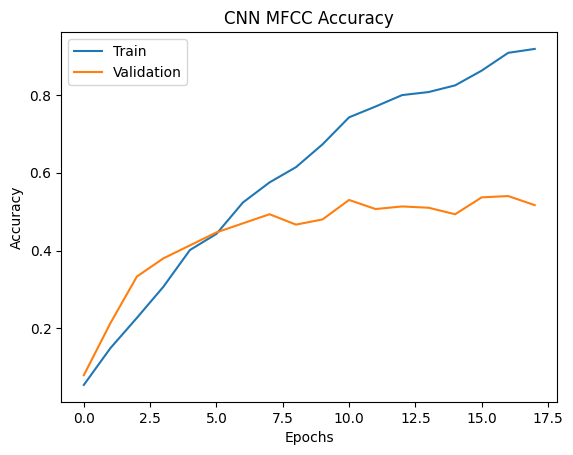

In [65]:
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Validation')
plt.title("CNN MFCC Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

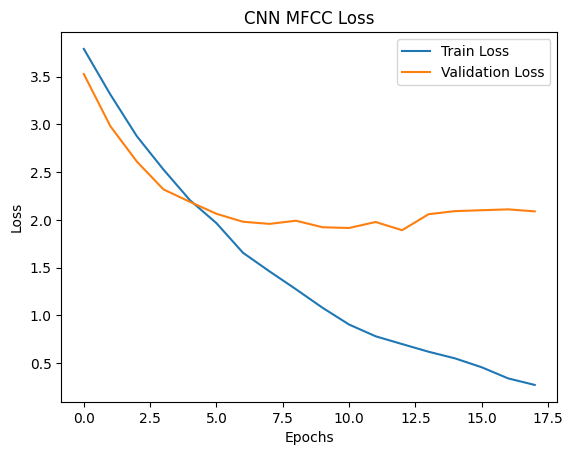

In [66]:
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title("CNN MFCC Loss")
plt.legend()
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.show()

In [16]:
def extract_mel_image(file_path):
    y, sr = librosa.load(file_path, duration=5)

    mel = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128)
    mel = librosa.power_to_db(mel)

    #  FIX LENGTH (important)
    mel = librosa.util.fix_length(mel, size=128, axis=1)

    return mel

In [17]:
X = []
y = []

for _, row in meta.iterrows():
    file_path = os.path.join(audio_path, row["filename"])

    mel = extract_mel_image(file_path)

    X.append(mel)
    y.append(row["target"])

X = np.array(X)[..., np.newaxis]
y = to_categorical(np.array(y), 50)

print("Shape:", X.shape)

Shape: (2000, 128, 128, 1)


In [18]:
X = (X - np.mean(X)) / np.std(X)
# Step 1 → 70% train, 30% temp
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# Step 2 → split temp into validation + test (15% each)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42
)
print("Train:", X_train.shape)
print("Val:", X_val.shape)
print("Test:", X_test.shape)

Train: (1400, 128, 128, 1)
Val: (300, 128, 128, 1)
Test: (300, 128, 128, 1)


In [19]:
model = Sequential([

    Conv2D(32, (3,3), activation='relu', input_shape=(128,128,1)),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),

    Dense(256, activation='relu'),
    Dropout(0.5),

    Dense(50, activation='softmax')
])
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 126, 126, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 12, 12, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │     1,179,904 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 50)             │        12,850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,433,010 (5.47 MB)

 Trainable params: 1,433,010 (5.47 MB)

 Non-trainable params: 0 (0.00 B)

In [20]:
optimizer = tf.keras.optimizers.Adam(learning_rate=0.0005)

model.compile(
    optimizer=optimizer,
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [79]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

lr_reduce = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3
)

history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_data=(X_val, y_val),
    callbacks=[early_stop, lr_reduce]
)

Epoch 1/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 59s 1s/step - accuracy: 0.0357 - loss: 3.8436 - val_accuracy: 0.0367 - val_loss: 3.7011 - learning_rate: 5.0000e-04
Epoch 2/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 74s 1s/step - accuracy: 0.0843 - loss: 3.5898 - val_accuracy: 0.1233 - val_loss: 3.4032 - learning_rate: 5.0000e-04
Epoch 3/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 80s 1s/step - accuracy: 0.1243 - loss: 3.3108 - val_accuracy: 0.1633 - val_loss: 3.1084 - learning_rate: 5.0000e-04
Epoch 4/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 83s 1s/step - accuracy: 0.1843 - loss: 3.0410 - val_accuracy: 0.2700 - val_loss: 2.8247 - learning_rate: 5.0000e-04
Epoch 5/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 81s 1s/step - accuracy: 0.2586 - loss: 2.7132 - val_accuracy: 0.3133 - val_loss: 2.6042 - learning_rate: 5.0000e-04
Epoch 6/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 83s 1s/step - accuracy: 0.3214 - loss: 2.4273 - val_accuracy: 0.3400 - val_loss: 2.2890 - learning_rate: 5.0000e-04
Epoch 7/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 47s 1s/step - accuracy: 0.3664 - loss:

In [80]:
loss, acc = model.evaluate(X_test, y_test)

print(" FINAL CNN + MEL ACCURACY:", acc)

10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 241ms/step - accuracy: 0.5733 - loss: 1.8582
 FINAL CNN + MEL ACCURACY: 0.5733333230018616


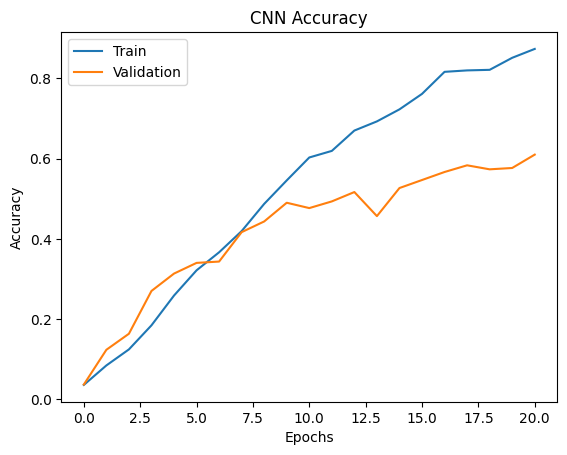

In [81]:

plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Validation')

plt.title("CNN Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()


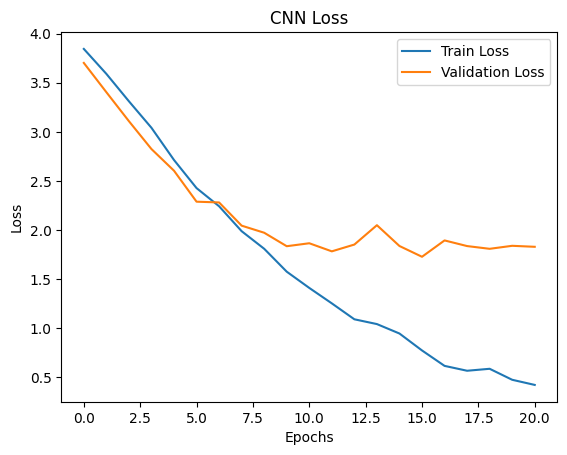

In [82]:
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title("CNN Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()


## Data Augmentation

To improve generalization, data augmentation is applied only to the training set. Techniques such as noise addition, pitch shifting, and time stretching are used to simulate real-world variations in audio signals.

In [44]:

from audiomentations import Compose, AddGaussianNoise, TimeStretch, PitchShift
augment = Compose([
    AddGaussianNoise(min_amplitude=0.001, max_amplitude=0.01, p=0.5),
    PitchShift(min_semitones=-2, max_semitones=2, p=0.4),
    TimeStretch(min_rate=0.9, max_rate=1.1, p=0.3)
])

In [46]:
def extract_mel(file_path, use_augment=False):
    y, sr = librosa.load(file_path, duration=5)


    if use_augment:
        y = augment(samples=y, sample_rate=sr)

    mel = librosa.feature.melspectrogram(
        y=y,
        sr=sr,
        n_mels=128,
        hop_length=512
    )

    mel = librosa.power_to_db(mel)

    # Fix time size (important)
    mel = librosa.util.fix_length(mel, size=256, axis=1)

    return mel

In [47]:
train_meta, temp_meta = train_test_split(meta, test_size=0.3, random_state=42)
val_meta, test_meta = train_test_split(temp_meta, test_size=0.5, random_state=42)

In [48]:
# TRAIN (WITH AUGMENTATION )
X_train = []
y_train = []

for _, row in train_meta.iterrows():
    file_path = os.path.join(audio_path, row["filename"])

    mel = extract_mel(file_path, use_augment=True)

    X_train.append(mel)
    y_train.append(row["target"])


# VALIDATION (NO AUGMENTATION )
X_val = []
y_val = []

for _, row in val_meta.iterrows():
    file_path = os.path.join(audio_path, row["filename"])

    mel = extract_mel(file_path, use_augment=False)

    X_val.append(mel)
    y_val.append(row["target"])


# TEST (NO AUGMENTATION )
X_test = []
y_test = []

for _, row in test_meta.iterrows():
    file_path = os.path.join(audio_path, row["filename"])

    mel = extract_mel(file_path, use_augment=False)

    X_test.append(mel)
    y_test.append(row["target"])

In [49]:
# Convert to numpy
X_train = np.array(X_train)[..., np.newaxis]
X_val = np.array(X_val)[..., np.newaxis]
X_test = np.array(X_test)[..., np.newaxis]

y_train = to_categorical(np.array(y_train), 50)
y_val = to_categorical(np.array(y_val), 50)
y_test = to_categorical(np.array(y_test), 50)

# Normalize per sample
X_train = (X_train - np.mean(X_train, axis=(1,2,3), keepdims=True)) / np.std(X_train, axis=(1,2,3), keepdims=True)
X_val = (X_val - np.mean(X_val, axis=(1,2,3), keepdims=True)) / np.std(X_val, axis=(1,2,3), keepdims=True)
X_test = (X_test - np.mean(X_test, axis=(1,2,3), keepdims=True)) / np.std(X_test, axis=(1,2,3), keepdims=True)

print("Train:", X_train.shape)
print("Val:", X_val.shape)
print("Test:", X_test.shape)

Train: (1400, 128, 256, 1)
Val: (300, 128, 256, 1)
Test: (300, 128, 256, 1)


## CRNN Model (CNN + LSTM)

A Convolutional Recurrent Neural Network (CRNN) is implemented. This model combines:

- CNN layers to extract spatial features from spectrograms
- LSTM layers to capture temporal dependencies in audio signals



In [50]:
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense, Dropout, Reshape, LSTM, BatchNormalization
from tensorflow.keras.models import Model

input_layer = Input(shape=(128, 256, 1))

# CNN
x = Conv2D(32, (3,3), activation='relu')(input_layer)
x = MaxPooling2D((2,2))(x)

x = Conv2D(64, (3,3), activation='relu')(x)
x = MaxPooling2D((2,2))(x)

x = Conv2D(128, (3,3), activation='relu')(x)
x = MaxPooling2D((2,2))(x)

# reshape for LSTM
shape = x.shape
x = Reshape((shape[2], shape[1]*shape[3]))(x)

# LSTM
x = LSTM(128, return_sequences=True)(x)
x = LSTM(64)(x)

x = BatchNormalization()(x)

# Dense
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)

output = Dense(50, activation='softmax')(x)

model = Model(inputs=input_layer, outputs=output)
model.summary()

Model: "functional_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_7 (InputLayer)      │ (None, 128, 256, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_22 (Conv2D)              │ (None, 126, 254, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_22 (MaxPooling2D) │ (None, 63, 127, 32)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_23 (Conv2D)              │ (None, 61, 125, 64)    │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_23 (MaxPooling2D) │ (None, 30, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_24 (Conv2D)              │ (None, 28, 60, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_24 (MaxPooling2D) │ (None, 14, 30, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_5 (Reshape)             │ (None, 30, 1792)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_10 (LSTM)                  │ (None, 30, 128)        │       983,552 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_11 (LSTM)                  │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 50)             │         6,450 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,140,658 (4.35 MB)

 Trainable params: 1,140,530 (4.35 MB)

 Non-trainable params: 128 (512.00 B)

## Model Training

The model is trained using the training dataset. EarlyStopping and learning rate scheduling are used to improve performance and prevent overfitting

In [51]:
import tensorflow as tf
optimizer = tf.keras.optimizers.Adam(learning_rate=0.0005)

model.compile(
    optimizer=optimizer,
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [52]:
import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
early_stop = EarlyStopping(patience=5, restore_best_weights=True)

lr_reduce = ReduceLROnPlateau(factor=0.3, patience=3)

history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_data=(X_val, y_val),
    callbacks=[early_stop, lr_reduce]
)

Epoch 1/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 67s 1s/step - accuracy: 0.0536 - loss: 3.7886 - val_accuracy: 0.0167 - val_loss: 3.8839 - learning_rate: 5.0000e-04
Epoch 2/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 81s 1s/step - accuracy: 0.1086 - loss: 3.4807 - val_accuracy: 0.0200 - val_loss: 3.8470 - learning_rate: 5.0000e-04
Epoch 3/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 83s 1s/step - accuracy: 0.1629 - loss: 3.1588 - val_accuracy: 0.0900 - val_loss: 3.6928 - learning_rate: 5.0000e-04
Epoch 4/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 80s 1s/step - accuracy: 0.2029 - loss: 2.9225 - val_accuracy: 0.1867 - val_loss: 3.4937 - learning_rate: 5.0000e-04
Epoch 5/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 83s 1s/step - accuracy: 0.2486 - loss: 2.7097 - val_accuracy: 0.1533 - val_loss: 3.3000 - learning_rate: 5.0000e-04
Epoch 6/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 62s 1s/step - accuracy: 0.2800 - loss: 2.5583 - val_accuracy: 0.2467 - val_loss: 2.9866 - learning_rate: 5.0000e-04
Epoch 7/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 82s 1s/step - accuracy: 0.3293 - loss:

In [53]:
loss, acc = model.evaluate(X_test, y_test)

print(" FINAL CRNN ACC")

10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 337ms/step - accuracy: 0.6567 - loss: 1.1461
 FINAL CRNN ACC


In [55]:
from sklearn.metrics import classification_report

# Make predictions on the test set
y_pred_crnn = model.predict(X_test)
y_pred_classes = np.argmax(y_pred_crnn, axis=1)
y_true_classes = np.argmax(y_test, axis=1)

# Get class names for the report
class_names = class_mapping.set_index('target')['category'].to_dict()

# Generate and print the classification report
report = classification_report(y_true_classes, y_pred_classes, target_names=[class_names[i] for i in sorted(class_names.keys())])
print("CRNN Model Classification Report (with augmentation):\n", report)

10/10 ━━━━━━━━━━━━━━━━━━━━ 5s 479ms/step
CRNN Model Classification Report (with augmentation):
                   precision    recall  f1-score   support

             dog       0.60      0.75      0.67         4
         rooster       0.71      0.83      0.77         6
             pig       0.75      0.75      0.75         4
             cow       1.00      0.86      0.92         7
            frog       0.67      0.57      0.62         7
             cat       1.00      0.40      0.57        10
             hen       0.88      0.78      0.82         9
         insects       0.40      1.00      0.57         2
           sheep       0.71      0.71      0.71         7
            crow       0.29      0.50      0.36         4
            rain       0.83      0.71      0.77         7
       sea_waves       0.50      0.50      0.50         6
  crackling_fire       0.33      0.40      0.36         5
        crickets       0.80      1.00      0.89         8
  chirping_birds       1.00      

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


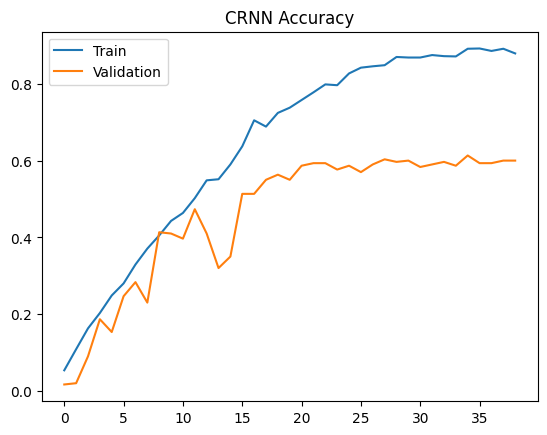

In [56]:
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Validation')
plt.title("CRNN Accuracy")
plt.legend()
plt.show()

In [28]:
from sklearn.metrics import classification_report

# Make predictions on the test set
y_pred_crnn = model.predict(X_test)
y_pred_classes = np.argmax(y_pred_crnn, axis=1)
y_true_classes = np.argmax(y_test, axis=1)

10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 333ms/step


In [57]:
# Get class names for the report
class_names = class_mapping.set_index('target')['category'].to_dict()

# Generate and print the classification report
report = classification_report(y_true_classes, y_pred_classes, target_names=[class_names[i] for i in sorted(class_names.keys())])
print("CRNN Model Classification Report:\n", report)

CRNN Model Classification Report:
                   precision    recall  f1-score   support

             dog       0.60      0.75      0.67         4
         rooster       0.71      0.83      0.77         6
             pig       0.75      0.75      0.75         4
             cow       1.00      0.86      0.92         7
            frog       0.67      0.57      0.62         7
             cat       1.00      0.40      0.57        10
             hen       0.88      0.78      0.82         9
         insects       0.40      1.00      0.57         2
           sheep       0.71      0.71      0.71         7
            crow       0.29      0.50      0.36         4
            rain       0.83      0.71      0.77         7
       sea_waves       0.50      0.50      0.50         6
  crackling_fire       0.33      0.40      0.36         5
        crickets       0.80      1.00      0.89         8
  chirping_birds       1.00      0.43      0.60         7
     water_drops       1.00      0.2

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


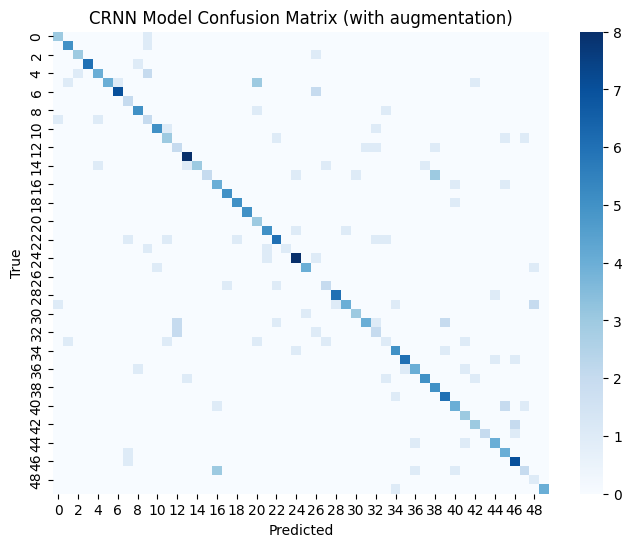

In [58]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

def plot_cm(y_test, y_pred, title):
    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(8,6))
    sns.heatmap(cm, cmap="Blues")
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.show()

plot_cm(y_true_classes, y_pred_classes, "CRNN Model Confusion Matrix (with augmentation)")

**CRNN without augmentaion(Best model)**

In [28]:
def extract_mel(file_path):
    y, sr = librosa.load(file_path, duration=5)

    mel = librosa.feature.melspectrogram(
        y=y,
        sr=sr,
        n_mels=128,
        hop_length=512
    )

    mel = librosa.power_to_db(mel)
    mel = librosa.util.fix_length(mel, size=256, axis=1)

    return mel

In [29]:
def build_data(metadata):
    X, y = [], []

    for _, row in metadata.iterrows():
        file_path = os.path.join(audio_path, row["filename"])

        mel = extract_mel(file_path)

        X.append(mel)
        y.append(row["target"])

    return np.array(X)[..., np.newaxis], to_categorical(np.array(y), 50)

X_train, y_train = build_data(train_meta)
X_val, y_val = build_data(val_meta)
X_test, y_test = build_data(test_meta)

In [32]:

# FEATURE (NO AUGMENTATION)
def extract_mel(file_path):
    y, sr = librosa.load(file_path, duration=5)

    mel = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128, hop_length=512)
    mel = librosa.power_to_db(mel)
    mel = librosa.util.fix_length(mel, size=256, axis=1)

    return mel


# SPLIT
train_meta, temp_meta = train_test_split(meta, test_size=0.3, random_state=42)
val_meta, test_meta = train_test_split(temp_meta, test_size=0.5, random_state=42)


# BUILD DATA
def build_data(metadata):
    X, y = [], []

    for _, row in metadata.iterrows():
        file_path = os.path.join(audio_path, row["filename"])
        mel = extract_mel(file_path)

        X.append(mel)
        y.append(row["target"])

    return np.array(X)[..., np.newaxis], to_categorical(np.array(y), 50)

X_train, y_train = build_data(train_meta)
X_val, y_val = build_data(val_meta)
X_test, y_test = build_data(test_meta)


# NORMALIZATION
X_train = (X_train - np.mean(X_train)) / np.std(X_train)
X_val = (X_val - np.mean(X_val)) / np.std(X_val)
X_test = (X_test - np.mean(X_test)) / np.std(X_test)


# MODEL
input_layer = Input(shape=(128, 256, 1))

x = Conv2D(32, (3,3), activation='relu')(input_layer)
x = MaxPooling2D((2,2))(x)

x = Conv2D(64, (3,3), activation='relu')(x)
x = MaxPooling2D((2,2))(x)

x = Conv2D(128, (3,3), activation='relu')(x)
x = MaxPooling2D((2,2))(x)

shape = x.shape
x = Reshape((shape[2], shape[1]*shape[3]))(x)

x = LSTM(128, return_sequences=True)(x)
x = LSTM(64)(x)

x = BatchNormalization()(x)

x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)

output = Dense(50, activation='softmax')(x)

model = Model(inputs=input_layer, outputs=output)
model.summary()


# COMPILE
model.compile(optimizer=tf.keras.optimizers.Adam(0.0005),
              loss='categorical_crossentropy',
              metrics=['accuracy'])


# TRAIN
history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_data=(X_val, y_val),
    callbacks=[EarlyStopping(patience=5, restore_best_weights=True),
               ReduceLROnPlateau(patience=3)]
)


# TEST
loss, acc = model.evaluate(X_test, y_test)
print("CRNN WITHOUT AUGMENTATION:", acc)


Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 128, 256, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 126, 254, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_16 (MaxPooling2D) │ (None, 63, 127, 32)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 61, 125, 64)    │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_17 (MaxPooling2D) │ (None, 30, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_18 (Conv2D)              │ (None, 28, 60, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_18 (MaxPooling2D) │ (None, 14, 30, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_3 (Reshape)             │ (None, 30, 1792)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_6 (LSTM)                   │ (None, 30, 128)        │       983,552 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_7 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 50)             │         6,450 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,140,658 (4.35 MB)

 Trainable params: 1,140,530 (4.35 MB)

 Non-trainable params: 128 (512.00 B)

Epoch 1/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 70s 1s/step - accuracy: 0.0371 - loss: 3.9158 - val_accuracy: 0.0167 - val_loss: 3.9030 - learning_rate: 5.0000e-04
Epoch 2/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 61s 1s/step - accuracy: 0.0814 - loss: 3.6420 - val_accuracy: 0.0600 - val_loss: 3.8600 - learning_rate: 5.0000e-04
Epoch 3/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 60s 1s/step - accuracy: 0.1114 - loss: 3.4176 - val_accuracy: 0.0800 - val_loss: 3.7711 - learning_rate: 5.0000e-04
Epoch 4/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 80s 1s/step - accuracy: 0.1386 - loss: 3.2080 - val_accuracy: 0.1333 - val_loss: 3.6341 - learning_rate: 5.0000e-04
Epoch 5/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 84s 1s/step - accuracy: 0.1786 - loss: 3.0185 - val_accuracy: 0.2033 - val_loss: 3.3922 - learning_rate: 5.0000e-04
Epoch 6/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 60s 1s/step - accuracy: 0.2300 - loss: 2.8273 - val_accuracy: 0.2100 - val_loss: 3.2339 - learning_rate: 5.0000e-04
Epoch 7/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 82s 1s/step - accuracy: 0.2500 - loss:

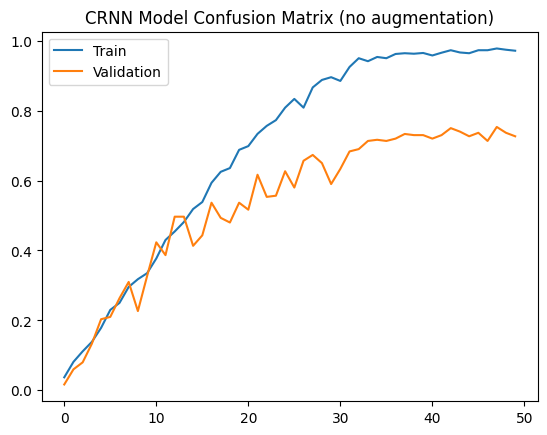

In [33]:

plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Validation')
plt.title("CRNN Model Confusion Matrix (no augmentation)")
plt.legend()
plt.show()

10/10 ━━━━━━━━━━━━━━━━━━━━ 5s 458ms/step


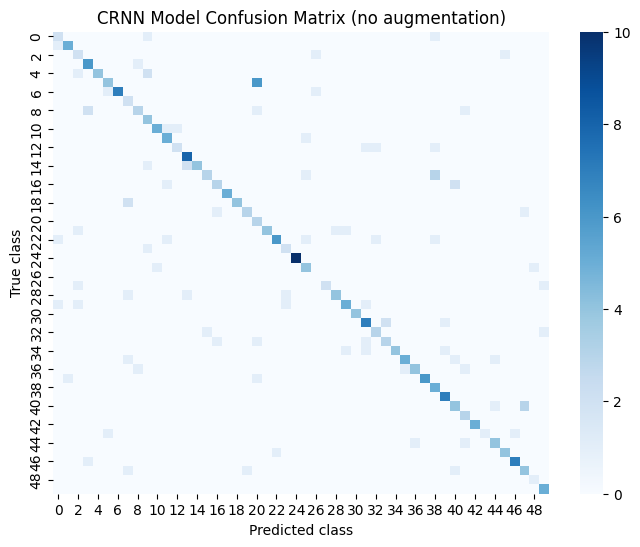

In [38]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np # Import numpy as it will be used for argmax

def plot_cm(y_test, y_pred, title):
    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(8,6))
    sns.heatmap(cm, cmap="Blues")
    plt.title(title)
    plt.xlabel("Predicted class")
    plt.ylabel("True class")
    plt.show()

# Make predictions on the test set for the non-augmented model
y_pred_crnn = model.predict(X_test)
y_pred_classes = np.argmax(y_pred_crnn, axis=1)
y_true_classes = np.argmax(y_test, axis=1)

plot_cm(y_true_classes, y_pred_classes, "CRNN Model Confusion Matrix (no augmentation)")